In [3]:
from __future__ import annotations

import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np

# Ensure local negf package is on the path
_here = Path().resolve()
_candidates = [_here, * _here.parents]
for base in _candidates:
    if (base / "negf").is_dir():
        sys.path.insert(0, str(base))
        break
    if (base / "src" / "negf").is_dir():
        sys.path.insert(0, str(base / "src"))
        break
else:
    raise ModuleNotFoundError("Cannot locate the negf package. Check the project path resolution.")

from negf.gf.recursive_greens_functions import gf_inverse
from negf import sancho_rubio_iterative_greens_function
from negf.utils.block_partition import (
    compute_block_sizes_block_tridiagonal,
    compute_block_sizes_metis,
 )

from pathlib import Path
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# Load QuantumATK reference data
_data_dir = Path("../DFT_data/TB_silicon_nw").resolve()

In [6]:
from pathlib import Path
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# Load QuantumATK reference data
_data_dir = Path("../DFT_data/TB_silicon_nw").resolve()
energy = np.load(_data_dir / "Energy_grid.npy")
H_device = np.load(_data_dir / "H_device.npy")
S_device = np.load(_data_dir / "S_device.npy")
sigma_L_ref = np.load(_data_dir / "Sigma_L_stack.npy")
sigma_R_ref = np.load(_data_dir / "Sigma_R_stack.npy")
H_left = np.load(_data_dir / "H_left.npy")
S_left = np.load(_data_dir / "S_left.npy")
H_right = np.load(_data_dir / "H_right.npy")
S_right = np.load(_data_dir / "S_right.npy")

n = H_left.shape[0] * 2
H_left = H_device[:n, :n]
S_left = S_device[:n, :n]
H_right = H_device[-n:, -n:]
S_right = S_device[-n:, -n:]
H01_L = H_device[:n, n:2*n]
H10_L = H_device[n:2*n, :n]
S01_L = S_device[:n, n:2*n]
S10_L = S_device[n:2*n, :n]
H01_R = H_device[-n:, -2*n:-n]
H10_R = H_device[-2*n:-n, -n:]
S01_R = S_device[-n:, -2*n:-n]
S10_R = S_device[-2*n:-n, -n:]

_eta = 1e-6
_damp = 1e-6
_tol = 1e-10

sigma_L_sr = np.array([
    sancho_rubio_iterative_greens_function(
        float(E),
        h_l=H01_L,
        h_0=H_left,
        h_r=H10_L,
        s_l=S01_L,
        s_0=S_left,
        s_r=S10_L,
        damp=_damp,
        nconv=_tol,
    )
    for E in energy
])

sigma_R_sr = np.array([
    sancho_rubio_iterative_greens_function(
        float(E),
        h_l=H01_R,
        h_0=H_right,
        h_r=H10_R,
        s_l=S01_R,
        s_0=S_right,
        s_r=S10_R,
        damp=_damp,
        nconv=_tol,
    )
    for E in energy
])

def embed_sigma(sigL, sigR):
    out = np.zeros_like(H_device, dtype=complex)
    a = sigL.shape[0]
    out[:a, :a] += sigL
    out[-a:, -a:] += sigR
    return out

rho_ref = []
rho_sr = []
for E, sigL_ref, sigR_ref, sigL_sr, sigR_sr in zip(energy, sigma_L_ref, sigma_R_ref, sigma_L_sr, sigma_R_sr):
    Sigma_ref = embed_sigma(sigL_ref, sigR_ref)
    Sigma_sr = embed_sigma(sigL_sr, sigR_sr)
    zS = (E + 1j * _eta) * S_device
    G_ref = np.linalg.inv(zS - H_device - Sigma_ref)
    G_sr = np.linalg.inv(zS - H_device - Sigma_sr)
    rho_ref.append(-np.imag(np.trace(G_ref @ S_device)) / np.pi)
    rho_sr.append(-np.imag(np.trace(G_sr @ S_device)) / np.pi)

rho_ref = np.array(rho_ref)
rho_sr = np.array(rho_sr)

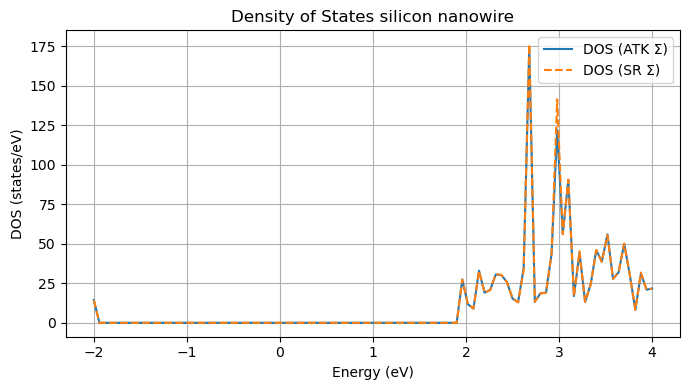

In [8]:
plt.figure(figsize=(7,4))
fermi_avg = -4.328434
plt.plot(energy - fermi_avg, rho_ref, label="DOS (ATK Σ)")
plt.plot(energy - fermi_avg, rho_sr, "--", label="DOS (SR Σ)")
plt.xlabel("Energy (eV)")
plt.ylabel("DOS (states/eV)")
plt.title("Density of States silicon nanowire")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


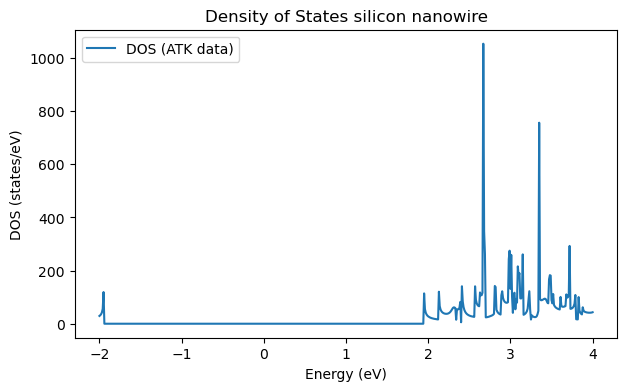

In [5]:
dos_energy = np.load(_data_dir / "DOS_energies.npy")
dos_total = np.load(_data_dir / "DOS_total.npy")

plt.figure(figsize=(7,4))
plt.plot(dos_energy, dos_total, label="DOS (ATK data)")
plt.title("Density of States silicon nanowire")
plt.xlabel("Energy (eV)")
plt.ylabel("DOS (states/eV)")
plt.legend()
plt.show()